# ВИЧ экспресс-тесты: диагностическая точность и SES-прокси

Открытые данные LSHTM Data Compass (без регистрации):

- **DATA.105** — несколько RDT vs референс `golds` ([Choko et al., PLOS ONE 2016](https://doi.org/10.1371/journal.pone.0158107))
- **DATA.7** — self-testing в Блантайре, Малави ([Choko et al.](https://doi.org/10.17037/DATA.7))

Таблицы DATA.7 **не связаны по id** — блоки B и C анализируются отдельно.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import binomtest
from sklearn.metrics import cohen_kappa_score, confusion_matrix

ROOT = Path("..").resolve() if (Path.cwd().name == "notebooks") else Path(".").resolve()
RDT_PATH = ROOT / "data/raw/lshtm_malawi/rdt_accuracy.txt"
ST_PATH = ROOT / "data/raw/lshtm_malawi_selftesting"

sns.set_theme(style="whitegrid")

In [2]:
def wilson_ci(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    """Wilson score interval for a binomial proportion."""
    if n == 0:
        return (np.nan, np.nan)
    result = binomtest(k, n).proportion_ci(confidence_level=1 - alpha, method="wilson")
    return result.low, result.high


def diagnostic_metrics(index: pd.Series, reference: pd.Series) -> dict:
    """Sensitivity, specificity, PPV, NPV and Wilson 95% CI."""
    df = pd.DataFrame({"index": index, "ref": reference}).dropna()
    df = df[df["index"].isin([0, 1]) & df["ref"].isin([0, 1])]
    tp = int(((df["index"] == 1) & (df["ref"] == 1)).sum())
    tn = int(((df["index"] == 0) & (df["ref"] == 0)).sum())
    fp = int(((df["index"] == 1) & (df["ref"] == 0)).sum())
    fn = int(((df["index"] == 0) & (df["ref"] == 1)).sum())
    sens_k, sens_n = tp, tp + fn
    spec_k, spec_n = tn, tn + fp
    ppv_k, ppv_n = tp, tp + fp
    npv_k, npv_n = tn, tn + fn
    sens_ci = wilson_ci(sens_k, sens_n)
    spec_ci = wilson_ci(spec_k, spec_n)
    ppv_ci = wilson_ci(ppv_k, ppv_n) if ppv_n else (np.nan, np.nan)
    npv_ci = wilson_ci(npv_k, npv_n) if npv_n else (np.nan, np.nan)
    kappa = cohen_kappa_score(df["ref"], df["index"]) if len(df) else np.nan
    return {
        "n": len(df),
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "sensitivity": sens_k / sens_n if sens_n else np.nan,
        "sensitivity_ci": sens_ci,
        "specificity": spec_k / spec_n if spec_n else np.nan,
        "specificity_ci": spec_ci,
        "ppv": ppv_k / ppv_n if ppv_n else np.nan,
        "ppv_ci": ppv_ci,
        "npv": npv_k / npv_n if npv_n else np.nan,
        "npv_ci": npv_ci,
        "kappa": kappa,
    }


def metrics_table(metrics_by_test: dict) -> pd.DataFrame:
    rows = []
    for name, m in metrics_by_test.items():
        rows.append({
            "test": name,
            "n": m["n"],
            "sensitivity": m["sensitivity"],
            "sens_ci_low": m["sensitivity_ci"][0],
            "sens_ci_high": m["sensitivity_ci"][1],
            "specificity": m["specificity"],
            "spec_ci_low": m["specificity_ci"][0],
            "spec_ci_high": m["specificity_ci"][1],
            "ppv": m["ppv"],
            "npv": m["npv"],
            "kappa": m["kappa"],
        })
    return pd.DataFrame(rows)

## Блок A — RDT vs референс `golds` (DATA.105)

Референс: параллельные оптимально хранимые Determine + Uni-Gold с tie-breaker при расхождении.

In [3]:
rdt = pd.read_csv(RDT_PATH, sep="\t")
for col in ["golds", "detn", "unign", "oqn", "deth", "unigh", "oqh"]:
    rdt[col] = pd.to_numeric(rdt[col], errors="coerce")

rdt_valid = rdt[rdt["golds"].isin([0, 1])].copy()
print(f"Участников с референсом: {len(rdt_valid)} из {len(rdt)}")
print(f"ВИЧ+ по golds: {(rdt_valid['golds'] == 1).sum()}")

rdt_tests = {
    "Determine (optimal)": "detn",
    "Uni-Gold (optimal)": "unign",
    "OraQuick (optimal)": "oqn",
    "Determine (sub-optimal)": "deth",
    "Uni-Gold (sub-optimal)": "unigh",
    "OraQuick (sub-optimal)": "oqh",
}

rdt_metrics = {
    label: diagnostic_metrics(rdt_valid[col], rdt_valid["golds"])
    for label, col in rdt_tests.items()
}
rdt_summary = metrics_table(rdt_metrics)
rdt_summary

Участников с референсом: 373 из 378
ВИЧ+ по golds: 181


,test,n,sensitivity,sens_ci_low,sens_ci_high,specificity,spec_ci_low,spec_ci_high,ppv,npv,kappa
0,Determine (optimal),371,0.994475,0.969373,0.999024,0.994737,0.970794,0.999070,0.994475,0.994737,0.989212
1,Uni-Gold (optimal),370,0.994475,0.969373,0.999024,1.000000,0.980080,1.000000,1.000000,0.994737,0.994591
2,OraQuick (optimal),364,0.983051,0.951360,0.994219,0.994652,0.970336,0.999055,0.994286,0.984127,0.977999
3,Determine (sub-optimal),371,0.994475,0.969373,0.999024,0.994737,0.970794,0.999070,0.994475,0.994737,0.989212
4,Uni-Gold (sub-optimal),370,0.994475,0.969373,0.999024,1.000000,0.980080,1.000000,1.000000,0.994737,0.994591
5,OraQuick (sub-optimal),370,0.972222,0.936632,0.988078,1.000000,0.980182,1.000000,1.000000,0.974359,0.972933


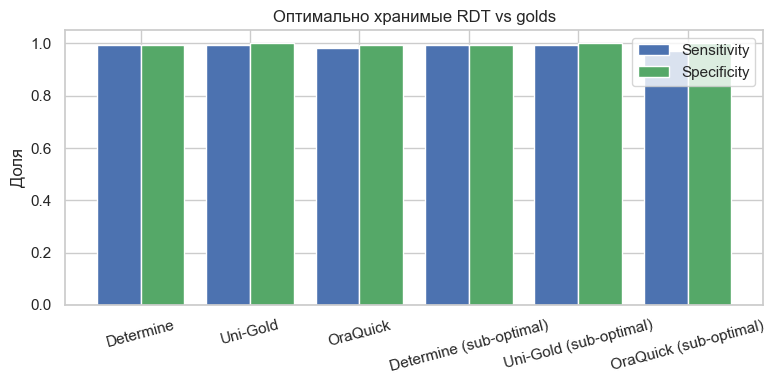

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
opt = rdt_summary[rdt_summary["test"].str.contains("optimal")]
x = np.arange(len(opt))
ax.bar(x - 0.2, opt["sensitivity"], 0.4, label="Sensitivity", color="#4C72B0")
ax.bar(x + 0.2, opt["specificity"], 0.4, label="Specificity", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels([t.replace(" (optimal)", "") for t in opt["test"]], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Доля")
ax.set_title("Оптимально хранимые RDT vs golds")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
def subgroup_metrics(data: pd.DataFrame, test_col: str, group_col: str) -> pd.DataFrame:
    rows = []
    for value, grp in data.groupby(group_col, dropna=True):
        m = diagnostic_metrics(grp[test_col], grp["golds"])
        rows.append({
            group_col: value,
            "n": m["n"],
            "sensitivity": m["sensitivity"],
            "specificity": m["specificity"],
        })
    return pd.DataFrame(rows)

rdt_valid["age_group"] = pd.cut(
    rdt_valid["age"], bins=[0, 24, 34, 100], labels=["<=24", "25-34", "35+"]
)

for var, label in [("sex", "Пол"), ("age_group", "Возраст"), ("testb4", "Тестировался ранее")]:
    sub = subgroup_metrics(rdt_valid, "oqn", var)
    print(f"\n--- OraQuick vs golds по: {label} ---")
    display(sub)


--- OraQuick vs golds по: Пол ---


,sex,n,sensitivity,specificity
0,1.0,190,1.000000,0.990654
1,2.0,167,0.967391,1.000000



--- OraQuick vs golds по: Возраст ---


,age_group,n,sensitivity,specificity
0,<=24,91,1.000000,0.985915
1,25-34,125,0.962963,1.000000
2,35+,148,0.990291,1.000000



--- OraQuick vs golds по: Тестировался ранее ---


,testb4,n,sensitivity,specificity
0,1.0,231,0.990196,0.992248
1,2.0,118,1.000000,1.000000


## Блок B — Self-test vs nurse RDT (`quality_assurance`)

`st` — self-reported self-test; `vct` — итог двух пальцевых RDT у медсестры.

In [6]:
qa = pd.read_csv(ST_PATH / "quality_assurance.txt", sep="\t")
qa = qa.dropna(how="all")
for col in ["st", "vct"]:
    qa[col] = pd.to_numeric(qa[col], errors="coerce")
qa = qa[qa["st"].isin([0, 1]) & qa["vct"].isin([0, 1])]

qa_m = diagnostic_metrics(qa["st"], qa["vct"])
print(f"Наблюдений: {qa_m['n']}")
print(f"Sensitivity: {qa_m['sensitivity']:.3f} {qa_m['sensitivity_ci']}")
print(f"Specificity: {qa_m['specificity']:.3f} {qa_m['specificity_ci']}")
print(f"PPV: {qa_m['ppv']:.3f}  NPV: {qa_m['npv']:.3f}  kappa: {qa_m['kappa']:.3f}")

cm = confusion_matrix(qa["vct"], qa["st"], labels=[0, 1])
pd.DataFrame(cm, index=["ref neg", "ref pos"], columns=["index neg", "index pos"])

Наблюдений: 1649
Sensitivity: 0.936 (np.float64(0.8831456427498141), np.float64(0.9660587287158677))
Specificity: 0.999 (np.float64(0.9962532644847243), np.float64(0.9998829316841183))
PPV: 0.992  NPV: 0.994  kappa: 0.960


,index neg,index pos
ref neg,1507,1
ref pos,9,132


## Блок C — SES-прокси: грамотность и охват self-testing

`lit` (грамотность) есть в `self_testing_individual_crude`, а `selftestprov` — в `revised`. Таблицы не связаны по id, поэтому объединяем на уровне страты (`cluster`, `r1`, `sex`, `agegp`).

Дополнительно: индивидуальный логит на дедуплицированных строках crude (`st` ~ `lit`).

In [7]:
crude = pd.read_csv(ST_PATH / "self_testing_individual_crude.txt", sep="\t")
revised = pd.read_csv(ST_PATH / "self_testing_individual_revised.txt", sep="\t")

crude_dedup = crude.drop_duplicates()
revised_dedup = revised.drop_duplicates()
keys = ["cluster", "r1", "sex", "agegp"]

lit_stratum = (
    crude_dedup.groupby(keys)["lit"]
    .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)
    .reset_index()
)
stratum = revised_dedup.merge(lit_stratum, on=keys, how="inner")
stratum = stratum.dropna(subset=["lit", "selftestprov"])
stratum["lit"] = stratum["lit"].astype(int)
stratum["selftestprov"] = stratum["selftestprov"].astype(int)

print("Страт (cluster x period x sex x age):", len(stratum))
print(stratum[["lit", "selftestprov"]].agg(["mean", "sum"]))

logit_stratum = smf.glm(
    "selftestprov ~ lit + C(sex) + C(agegp) + C(cluster)",
    data=stratum,
    family=sm.families.Binomial(),
).fit(cov_type="cluster", cov_kwds={"groups": stratum["cluster"]})
print(logit_stratum.summary())

Страт (cluster x period x sex x age): 487
             lit  selftestprov
mean    0.979466      0.574949
sum   477.000000    280.000000
                 Generalized Linear Model Regression Results                  
Dep. Variable:           selftestprov   No. Observations:                  487
Model:                            GLM   Df Residuals:                      467
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -318.08
Date:                Sun, 21 Jun 2026   Deviance:                       636.16
Time:                        15:31:00   Pearson chi2:                     482.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05584
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025   

In [8]:
ind = crude_dedup.dropna(subset=["lit", "st"]).copy()
ind["lit"] = ind["lit"].astype(int)
ind["st"] = ind["st"].astype(int)

logit_ind = smf.glm(
    "st ~ lit + C(sex) + C(agegp) + C(cluster)",
    data=ind,
    family=sm.families.Binomial(),
).fit(cov_type="cluster", cov_kwds={"groups": ind["cluster"]})
print("Индивидуальный уровень (outcome: ever self-tested, crude dedup):")
print(logit_ind.summary())

odds = np.exp(logit_ind.params["lit"])
print(f"\nOR грамотности (lit): {odds:.2f}")

ValueError: The weights and list don't have the same length.

## Выводы

1. **DATA.105** позволяет оценить чувствительность/специфичность нескольких RDT на индивидуальном уровне.
2. **quality_assurance** даёт валидацию self-test vs nurse RDT, но без SES-переменных.
3. **Грамотность** (`lit`) связана с охватом/поведением тестирования, но не с точностью теста на индивидуальном уровне из-за дизайна анонимизации DATA.7.
4. Wealth index требует DHS/PHIA с одобрением — см. `data/README.md`.